# Runs Analysis
Comparative analysis of ForecastingAE vs Blind model across the 18-configuration Cartesian grid.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

RUNS_PATH = '../data/out/models_comparison/runs.csv'

In [18]:
df_raw = pd.read_csv(RUNS_PATH)
# Strip stray leading apostrophes from numeric columns
for col in df_raw.columns:
    if df_raw[col].dtype == object:
        cleaned = df_raw[col].astype(str).str.lstrip("'")
        try:
            df_raw[col] = pd.to_numeric(cleaned)
        except (ValueError, TypeError):
            df_raw[col] = cleaned

df = df_raw[df_raw['Status'] == 'FINISHED'].copy()
df['t_in']       = df['t_in'].astype(int)
df['t_out']      = df['t_out'].astype(int)
df['latent_dim'] = df['latent_dim'].astype(int)
df = df.sort_values(['t_in', 't_out', 'latent_dim']).reset_index(drop=True)
print(f'Runs loaded: {len(df)}')
display(df[['Name', 't_in', 't_out', 'latent_dim']])

Runs loaded: 18


,Name,t_in,t_out,latent_dim
0,tin12-tout1-latent20,12,1,20
1,tin12-tout1-latent40,12,1,40
2,tin12-tout1-latent80,12,1,80
3,tin12-tout4-latent20,12,4,20
4,tin12-tout4-latent40,12,4,40
5,tin12-tout4-latent80,12,4,80
6,tin16-tout1-latent20,16,1,20
7,tin16-tout1-latent40,16,1,40
8,tin16-tout1-latent80,16,1,80
9,tin16-tout4-latent20,16,4,20


## 1. Loss Comparison (MSE / MAE / Smooth-L1)
Training (in-sample) and OOS metrics for contextual vs blind model.

## 0. Representative Run Selection (Median Performer)
Select the configuration whose contextual OOS MSE is closest to the cross-configuration median — used for all qualitative figures.

In [19]:
median_mse = df['oos_mse_contextual'].median()
median_idx = (df['oos_mse_contextual'] - median_mse).abs().idxmin()
representative = df.loc[median_idx]

print(f"Median OOS MSE across 18 runs : {median_mse:.6f}")
print(f"Representative run            : {representative['Name']}")
print(f"  Run ID  : {representative['Run ID']}")
print(f"  t_in    : {int(representative['t_in'])}")
print(f"  t_out   : {int(representative['t_out'])}")
print(f"  latent  : {int(representative['latent_dim'])}")
print(f"  OOS MSE : {representative['oos_mse_contextual']:.6f}")

REPRESENTATIVE_RUN_ID = representative['Run ID']

Median OOS MSE across 18 runs : 0.020537
Representative run            : tin12-tout4-latent80
  Run ID  : fe9eddd03b4e46d38ff6d7cb32ffd263
  t_in    : 12
  t_out   : 4
  latent  : 80
  OOS MSE : 0.020994


In [20]:
loss_table = df[[
    't_in', 't_out', 'latent_dim',
    'mse_contextual', 'mse_blind',
    'oos_mse_contextual', 'oos_mse_blind', 'oos_macro_gain',
    'mae_contextual', 'mae_blind',
    'oos_mae_contextual', 'oos_mae_blind',
    'smooth_l1_contextual', 'smooth_l1_blind',
]].copy()
loss_table.columns = [
    't_in', 't_out', 'latent_dim',
    'MSE (ctx)', 'MSE (blind)',
    'OOS MSE (ctx)', 'OOS MSE (blind)', 'OOS Macro Gain',
    'MAE (ctx)', 'MAE (blind)',
    'OOS MAE (ctx)', 'OOS MAE (blind)',
    'SmoothL1 (ctx)', 'SmoothL1 (blind)',
]
display(loss_table.mean())

t_in               16.0000
t_out               2.5000
latent_dim         46.6667
MSE (ctx)           0.0217
MSE (blind)         0.0228
OOS MSE (ctx)       0.0205
OOS MSE (blind)     0.0210
OOS Macro Gain      0.0006
MAE (ctx)           0.0473
MAE (blind)         0.0475
OOS MAE (ctx)       0.0449
OOS MAE (blind)     0.0447
SmoothL1 (ctx)      0.0098
SmoothL1 (blind)    0.0102
dtype: float64

## 2. Feature Importance
Saliency macro ratio for latent and reconstruction modes.

In [21]:
saliency_table = df[[
    't_in', 't_out', 'latent_dim',
    'latent_macro_ratio',
    'reconstruction_macro_ratio',
]].copy()
saliency_table.columns = [
    't_in', 't_out', 'latent_dim',
    'Macro Ratio — Latent (IG)',
    'Macro Ratio — Reconstruction (IG)',
]
display(saliency_table.mean())

t_in                                16.0000
t_out                                2.5000
latent_dim                          46.6667
Macro Ratio — Latent (IG)            0.4282
Macro Ratio — Reconstruction (IG)    0.1126
dtype: float64

## 4. Variance Explanation (R² Linear Probing)
R² of linear probes predicting macro and financial features from latent and reconstruction.

In [22]:
r2_table = df[[
    't_in', 't_out', 'latent_dim',
    'macro_linear_probe_r2_latent',
    'macro_linear_probe_r2_recon',
    'financial_linear_probe_r2_latent',
    'financial_linear_probe_r2_recon',
]].copy()
r2_table.columns = [
    't_in', 't_out', 'latent_dim',
    'R² Macro → Latent',
    'R² Macro → Recon',
    'R² Financial → Latent',
    'R² Financial → Recon',
]
display(r2_table.mean())

t_in                    16.0000
t_out                    2.5000
latent_dim              46.6667
R² Macro → Latent        0.7520
R² Macro → Recon         0.1599
R² Financial → Latent    0.6068
R² Financial → Recon     0.5974
dtype: float64

## 5. Comprehensive Table (all metrics per configuration)

In [23]:
all_metrics = [
    't_in', 't_out', 'latent_dim',
    # Loss
    'mse_contextual', 'mse_blind', 'oos_mse_contextual', 'oos_mse_blind', 'oos_macro_gain',
    'mae_contextual', 'mae_blind', 'oos_mae_contextual', 'oos_mae_blind',
    'smooth_l1_contextual', 'smooth_l1_blind',
    # Saliency
    'latent_macro_ratio', 'reconstruction_macro_ratio',
    # Geometry
    'cosine_contextual_mean', 'cosine_blind_mean',
    'l2_contextual_mean', 'l2_blind_mean',
    # R2
    'macro_linear_probe_r2_latent', 'macro_linear_probe_r2_recon',
    'financial_linear_probe_r2_latent', 'financial_linear_probe_r2_recon',
]

comprehensive = df[all_metrics].copy()
display(comprehensive.round(4))

,t_in,t_out,latent_dim,mse_contextual,mse_blind,oos_mse_contextual,oos_mse_blind,oos_macro_gain,mae_contextual,mae_blind,oos_mae_contextual,oos_mae_blind,smooth_l1_contextual,smooth_l1_blind,latent_macro_ratio,reconstruction_macro_ratio,cosine_contextual_mean,cosine_blind_mean,l2_contextual_mean,l2_blind_mean,macro_linear_probe_r2_latent,macro_linear_probe_r2_recon,financial_linear_probe_r2_latent,financial_linear_probe_r2_recon
0,12,1,20,0.0215,0.0234,0.0194,0.0205,0.0011,0.0477,0.0483,0.0432,0.0442,0.0097,0.0104,0.4899,0.1366,0.0741,0.0000,0.6612,0,0.4176,0.0853,0.4562,0.5089
1,12,1,40,0.0171,0.0183,0.0161,0.0168,0.0008,0.0437,0.0443,0.0424,0.0426,0.0078,0.0083,0.3518,0.0778,0.0952,-0.0000,0.6366,0,0.7335,0.1537,0.6011,0.6066
2,12,1,80,0.0143,0.0149,0.0138,0.0142,0.0004,0.0407,0.0408,0.0402,0.0400,0.0066,0.0068,0.4826,0.0700,0.0765,0.0000,0.4621,0,0.9161,0.2035,0.7578,0.6332
3,12,4,20,0.0296,0.0310,0.0264,0.0273,0.0009,0.0519,0.0521,0.0481,0.0475,0.0129,0.0135,0.4379,0.1248,0.2003,0.0000,0.9969,0,0.5879,0.1428,0.4868,0.5265
4,12,4,40,0.0260,0.0271,0.0239,0.0245,0.0006,0.0495,0.0496,0.0461,0.0449,0.0116,0.0120,0.3676,0.1321,0.2037,0.0000,1.0686,0,0.8822,0.2104,0.6251,0.6336
5,12,4,80,0.0219,0.0229,0.0210,0.0217,0.0007,0.0469,0.0472,0.0442,0.0437,0.0099,0.0104,0.4954,0.0860,0.1483,0.0000,0.8521,0,0.9906,0.2367,0.7732,0.7356
6,16,1,20,0.0217,0.0233,0.0200,0.0210,0.0010,0.0480,0.0495,0.0452,0.0469,0.0098,0.0104,0.4484,0.1262,0.0883,0.0000,0.6150,0,0.3908,0.0661,0.4524,0.5050
7,16,1,40,0.0169,0.0178,0.0163,0.0168,0.0006,0.0441,0.0444,0.0415,0.0431,0.0078,0.0081,0.3786,0.0911,0.1092,-0.0000,0.8297,0,0.7866,0.1266,0.5998,0.6050
8,16,1,80,0.0139,0.0144,0.0134,0.0139,0.0005,0.0407,0.0405,0.0379,0.0388,0.0064,0.0066,0.3431,0.0709,0.1305,0.0000,0.6393,0,0.9870,0.1746,0.7397,0.6166
9,16,4,20,0.0299,0.0310,0.0273,0.0279,0.0005,0.0530,0.0527,0.0494,0.0490,0.0131,0.0136,0.3663,0.1571,0.1733,-0.0000,0.9438,0,0.5715,0.1180,0.4862,0.5181


## 6. Average Summary: Contextual vs Blind across all 18 configurations

In [24]:
summary_pairs = [
    ('MSE (in-sample)',      'mse_contextual',                  'mse_blind'),
    ('MSE (OOS)',            'oos_mse_contextual',              'oos_mse_blind'),
    ('MAE (in-sample)',      'mae_contextual',                  'mae_blind'),
    ('MAE (OOS)',            'oos_mae_contextual',              'oos_mae_blind'),
    ('Smooth-L1 (in-sample)','smooth_l1_contextual',           'smooth_l1_blind'),
    ('Cosine Mean',          'cosine_contextual_mean',          'cosine_blind_mean'),
    ('L2 Mean',              'l2_contextual_mean',              'l2_blind_mean'),
    ('Cosine CV',            'cosine_contextual_cv',            'cosine_blind_cv'),
    ('L2 CV',                'l2_contextual_cv',                'l2_blind_cv'),
    ('R² Macro → Latent',    'macro_linear_probe_r2_latent',    None),
    ('R² Macro → Recon',     'macro_linear_probe_r2_recon',     None),
    ('R² Financial → Latent','financial_linear_probe_r2_latent',None),
    ('R² Financial → Recon', 'financial_linear_probe_r2_recon', None),
    ('Macro Ratio (Latent IG)',       'latent_macro_ratio',     None),
    ('Macro Ratio (Recon IG)',        'reconstruction_macro_ratio', None),
    ('OOS Macro Gain',       'oos_macro_gain',                  None),
]

rows = []
for label, ctx_col, blind_col in summary_pairs:
    row = {'Metric': label}
    if ctx_col:
        row['Contextual (mean)'] = df[ctx_col].mean()
        row['Contextual (std)']  = df[ctx_col].std()
    else:
        row['Contextual (mean)'] = np.nan
        row['Contextual (std)']  = np.nan
    if blind_col:
        row['Blind (mean)'] = df[blind_col].mean()
        row['Blind (std)']  = df[blind_col].std()
    else:
        row['Blind (mean)'] = np.nan
        row['Blind (std)']  = np.nan
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Metric')
display(summary)

,Contextual (mean),Contextual (std),Blind (mean),Blind (std)
Metric,,,,
MSE (in-sample),0.0217,0.0054,0.0228,0.0056
MSE (OOS),0.0205,0.0048,0.0210,0.0048
MAE (in-sample),0.0473,0.0041,0.0475,0.0040
MAE (OOS),0.0449,0.0035,0.0447,0.0027
Smooth-L1 (in-sample),0.0098,0.0023,0.0102,0.0023
Cosine Mean,0.1378,0.0632,0.0000,0.0000
L2 Mean,0.8037,0.2528,0.0000,0.0000
Cosine CV,0.8467,0.1523,-5960.0302,25475.4537
L2 CV,0.6958,0.1925,0.0000,0.0000


## 7. OOS Macro Gain distribution across configurations

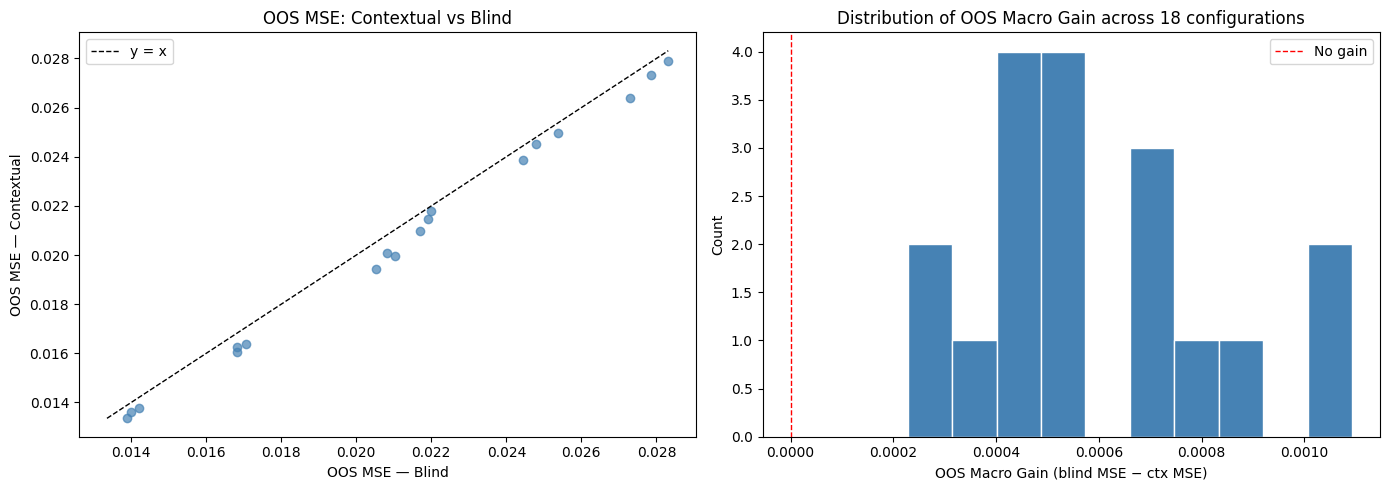

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OOS MSE: contextual vs blind
axes[0].scatter(df['oos_mse_blind'], df['oos_mse_contextual'], c='steelblue', alpha=0.7)
lims = [min(df['oos_mse_blind'].min(), df['oos_mse_contextual'].min()),
        max(df['oos_mse_blind'].max(), df['oos_mse_contextual'].max())]
axes[0].plot(lims, lims, 'k--', linewidth=1, label='y = x')
axes[0].set_xlabel('OOS MSE — Blind')
axes[0].set_ylabel('OOS MSE — Contextual')
axes[0].set_title('OOS MSE: Contextual vs Blind')
axes[0].legend()

# Macro Gain distribution
axes[1].hist(df['oos_macro_gain'], bins=10, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1, label='No gain')
axes[1].set_xlabel('OOS Macro Gain (blind MSE − ctx MSE)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of OOS Macro Gain across 18 configurations')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Statistical Significance — Wilcoxon Signed-Rank Test
Paired non-parametric test (H₁: contextual better than blind) across 18 matched configurations.

In [26]:
from scipy.stats import wilcoxon

# Each tuple: (label, contextual_col, blind_col, alternative)
# alternative='less' means H1: contextual < blind (lower is better for losses)
# alternative='greater' means H1: contextual > blind (higher is better for geometry/R2)
test_pairs = [
    ('MSE (in-sample)',       'mse_contextual',                  'mse_blind',             'less'),
    ('MSE (OOS)',             'oos_mse_contextual',              'oos_mse_blind',          'less'),
    ('MAE (in-sample)',       'mae_contextual',                  'mae_blind',              'less'),
    ('MAE (OOS)',             'oos_mae_contextual',              'oos_mae_blind',          'less'),
    ('Smooth-L1 (in-sample)', 'smooth_l1_contextual',           'smooth_l1_blind',        'less'),
    ('Spearman Cosine',       'spearman_cosine',                 None,                     None),
    ('Spearman Euclidean',    'spearman_euclidean',              None,                     None),
    ('R² Macro → Latent',     'macro_linear_probe_r2_latent',   None,                     None),
    ('R² Macro → Recon',      'macro_linear_probe_r2_recon',    None,                     None),
    ('R² Financial → Latent', 'financial_linear_probe_r2_latent', None,                   None),
    ('R² Financial → Recon',  'financial_linear_probe_r2_recon',  None,                   None),
]

rows = []
for label, ctx_col, blind_col, alt in test_pairs:
    ctx_vals = df[ctx_col].values
    if blind_col is not None:
        blind_vals = df[blind_col].values
        diffs = ctx_vals - blind_vals
        stat, p = wilcoxon(diffs, alternative=alt)
        n = len(diffs)
        # rank-biserial correlation effect size
        r = 1 - (2 * stat) / (n * (n + 1))
        rows.append({
            'Metric': label,
            'Contextual median': round(float(pd.Series(ctx_vals).median()), 5),
            'Blind median':      round(float(pd.Series(blind_vals).median()), 5),
            'W': round(stat, 1),
            'p-value (one-sided)': round(p, 4),
            'r (effect size)': round(r, 3),
            'Significant (α=0.05)': '✓' if p < 0.05 else '✗',
        })
    else:
        rows.append({
            'Metric': label,
            'Contextual median': round(float(pd.Series(ctx_vals).median()), 5),
            'Blind median': '—',
            'W': '—', 'p-value (one-sided)': '—',
            'r (effect size)': '—', 'Significant (α=0.05)': '—',
        })

wilcoxon_table = pd.DataFrame(rows).set_index('Metric')
display(wilcoxon_table)

,Contextual median,Blind median,W,p-value (one-sided),r (effect size),Significant (α=0.05)
Metric,,,,,,
MSE (in-sample),0.0217,0.0230,0.0000,0.0000,1.0000,✓
MSE (OOS),0.0205,0.0214,0.0000,0.0000,1.0000,✓
MAE (in-sample),0.0478,0.0483,39.0000,0.0216,0.7720,✓
MAE (OOS),0.0452,0.0450,103.0000,0.7789,0.3980,✗
Smooth-L1 (in-sample),0.0098,0.0104,0.0000,0.0000,1.0000,✓
Spearman Cosine,0.9171,—,—,—,—,—
Spearman Euclidean,0.9504,—,—,—,—,—
R² Macro → Latent,0.8170,—,—,—,—,—
R² Macro → Recon,0.1489,—,—,—,—,—


## 9. LaTeX Table Export
Cells below print ready-to-paste LaTeX tables for the paper.

In [27]:
def bold_best(df, col_map, lower_better=(), higher_better=(), fmt='%.4f'):
    """
    Format a DataFrame for LaTeX, bolding the best value per metric column.

    df            : raw numeric DataFrame (original column names)
    col_map       : list of (raw_col, latex_col) — column selection and renaming
    lower_better  : raw column names where the minimum is best
    higher_better : raw column names where the maximum is best
    fmt           : printf-style format for float values

    Returns a string DataFrame with LaTeX column names ready for .to_latex(escape=False).
    """
    raw_to_lat = dict(col_map)
    str_df = pd.DataFrame(index=df.index)

    for raw_col, lat_col in col_map:
        col = df[raw_col]
        if pd.api.types.is_float_dtype(col):
            str_df[lat_col] = col.map(lambda x, f=fmt: f % x)
        else:
            str_df[lat_col] = col.astype(str)

    for raw_col in lower_better:
        best_idx = df[raw_col].idxmin()
        lat_col  = raw_to_lat[raw_col]
        str_df.loc[best_idx, lat_col] = r'\textbf{' + (fmt % df.loc[best_idx, raw_col]) + r'}'

    for raw_col in higher_better:
        best_idx = df[raw_col].idxmax()
        lat_col  = raw_to_lat[raw_col]
        str_df.loc[best_idx, lat_col] = r'\textbf{' + (fmt % df.loc[best_idx, raw_col]) + r'}'

    return str_df


In [28]:
# ── Table 1: MSE (in-sample and OOS) per configuration ──────────────────────
col_map_t1 = [
    ('t_in',               r'$T_\mathrm{in}$'),
    ('t_out',              r'$T_\mathrm{out}$'),
    ('latent_dim',         r'$d_z$'),
    ('mse_contextual',     r'MSE$^\mathrm{ctx}$'),
    ('mse_blind',          r'MSE$^\mathrm{blind}$'),
    ('oos_mse_contextual', r'OOS-MSE$^\mathrm{ctx}$'),
    ('oos_mse_blind',      r'OOS-MSE$^\mathrm{blind}$'),
]
lower_t1 = ['mse_contextual', 'mse_blind', 'oos_mse_contextual', 'oos_mse_blind']

t1 = bold_best(df, col_map_t1, lower_better=lower_t1)

latex_t1 = (
    "\\begin{table}[t]\n"
    "\\caption{In-sample and out-of-sample MSE for all 18 configurations. "
    "Contextual (ctx) vs.\\ blind model. Bold = best per column.}\n"
    "\\label{tab:mse}\n"
    "\\centering\n"
    + t1.to_latex(index=False, escape=False)
    + "\\end{table}"
)
print(latex_t1)


\begin{table}[t]
\caption{In-sample and out-of-sample MSE for all 18 configurations. Contextual (ctx) vs.\ blind model. Bold = best per column.}
\label{tab:mse}
\centering
\begin{tabular}{lllllll}
\toprule
$T_\mathrm{in}$ & $T_\mathrm{out}$ & $d_z$ & MSE$^\mathrm{ctx}$ & MSE$^\mathrm{blind}$ & OOS-MSE$^\mathrm{ctx}$ & OOS-MSE$^\mathrm{blind}$ \\
\midrule
12 & 1 & 20 & 0.0215 & 0.0234 & 0.0194 & 0.0205 \\
12 & 1 & 40 & 0.0171 & 0.0183 & 0.0161 & 0.0168 \\
12 & 1 & 80 & 0.0143 & 0.0149 & 0.0138 & 0.0142 \\
12 & 4 & 20 & 0.0296 & 0.0310 & 0.0264 & 0.0273 \\
12 & 4 & 40 & 0.0260 & 0.0271 & 0.0239 & 0.0245 \\
12 & 4 & 80 & 0.0219 & 0.0229 & 0.0210 & 0.0217 \\
16 & 1 & 20 & 0.0217 & 0.0233 & 0.0200 & 0.0210 \\
16 & 1 & 40 & 0.0169 & 0.0178 & 0.0163 & 0.0168 \\
16 & 1 & 80 & 0.0139 & \textbf{0.0144} & \textbf{0.0134} & \textbf{0.0139} \\
16 & 4 & 20 & 0.0299 & 0.0310 & 0.0273 & 0.0279 \\
16 & 4 & 40 & 0.0261 & 0.0271 & 0.0245 & 0.0248 \\
16 & 4 & 80 & 0.0220 & 0.0229 & 0.0215 & 0.0219 \\
20 &

In [29]:
# ── Table 2: Integrated Gradients macro ratio per configuration ───────────────
col_map_t2 = [
    ('t_in',                        r'$T_\mathrm{in}$'),
    ('t_out',                       r'$T_\mathrm{out}$'),
    ('latent_dim',                  r'$d_z$'),
    ('latent_macro_ratio',          r'Macro ratio — latent IG'),
    ('reconstruction_macro_ratio',  r'Macro ratio — reconstruction IG'),
]
higher_t2 = ['latent_macro_ratio', 'reconstruction_macro_ratio']

t2 = bold_best(df, col_map_t2, higher_better=higher_t2)

latex_t2 = (
    "\\begin{table}[t]\n"
    "\\caption{Integrated Gradients macro attribution ratio for all 18 configurations. "
    "Values indicate the fraction of total IG mass attributed to macro inputs. "
    "Bold = highest per column.}\n"
    "\\label{tab:ig}\n"
    "\\centering\n"
    + t2.to_latex(index=False, escape=False)
    + "\\end{table}"
)
print(latex_t2)


\begin{table}[t]
\caption{Integrated Gradients macro attribution ratio for all 18 configurations. Values indicate the fraction of total IG mass attributed to macro inputs. Bold = highest per column.}
\label{tab:ig}
\centering
\begin{tabular}{lllll}
\toprule
$T_\mathrm{in}$ & $T_\mathrm{out}$ & $d_z$ & Macro ratio — latent IG & Macro ratio — reconstruction IG \\
\midrule
12 & 1 & 20 & 0.4899 & 0.1366 \\
12 & 1 & 40 & 0.3518 & 0.0778 \\
12 & 1 & 80 & 0.4826 & 0.0700 \\
12 & 4 & 20 & 0.4379 & 0.1248 \\
12 & 4 & 40 & 0.3676 & 0.1321 \\
12 & 4 & 80 & 0.4954 & 0.0860 \\
16 & 1 & 20 & 0.4484 & 0.1262 \\
16 & 1 & 40 & 0.3786 & 0.0911 \\
16 & 1 & 80 & 0.3431 & 0.0709 \\
16 & 4 & 20 & 0.3663 & 0.1571 \\
16 & 4 & 40 & \textbf{0.5559} & 0.1466 \\
16 & 4 & 80 & 0.4870 & 0.1118 \\
20 & 1 & 20 & 0.2375 & 0.1501 \\
20 & 1 & 40 & 0.4826 & 0.0826 \\
20 & 1 & 80 & 0.4160 & 0.0547 \\
20 & 4 & 20 & 0.4600 & \textbf{0.1579} \\
20 & 4 & 40 & 0.4557 & 0.1297 \\
20 & 4 & 80 & 0.4521 & 0.1213 \\
\bottomrule
\en

In [30]:
# ── Table 3: R² linear probing per configuration ─────────────────────────────
col_map_t3 = [
    ('t_in',                              r'$T_\mathrm{in}$'),
    ('t_out',                             r'$T_\mathrm{out}$'),
    ('latent_dim',                        r'$d_z$'),
    ('macro_linear_probe_r2_latent',      r'$R^2_\mathrm{mac}$ (latent)'),
    ('macro_linear_probe_r2_recon',       r'$R^2_\mathrm{mac}$ (recon)'),
    ('financial_linear_probe_r2_latent',  r'$R^2_\mathrm{fin}$ (latent)'),
    ('financial_linear_probe_r2_recon',   r'$R^2_\mathrm{fin}$ (recon)'),
]
higher_t3 = [
    'macro_linear_probe_r2_latent', 'macro_linear_probe_r2_recon',
    'financial_linear_probe_r2_latent', 'financial_linear_probe_r2_recon',
]

t3 = bold_best(df, col_map_t3, higher_better=higher_t3)

latex_t3 = (
    "\\begin{table}[t]\n"
    "\\caption{Linear probing $R^2$ for all 18 configurations. "
    "Each column reports the variance in macro or financial features explained "
    "by the latent representation $\\mathbf{z}$ or reconstruction $\\hat{\\mathbf{x}}$. "
    "Bold = best per column.}\n"
    "\\label{tab:r2_full}\n"
    "\\centering\n"
    + t3.to_latex(index=False, escape=False)
    + "\\end{table}"
)
print(latex_t3)


\begin{table}[t]
\caption{Linear probing $R^2$ for all 18 configurations. Each column reports the variance in macro or financial features explained by the latent representation $\mathbf{z}$ or reconstruction $\hat{\mathbf{x}}$. Bold = best per column.}
\label{tab:r2_full}
\centering
\begin{tabular}{lllllll}
\toprule
$T_\mathrm{in}$ & $T_\mathrm{out}$ & $d_z$ & $R^2_\mathrm{mac}$ (latent) & $R^2_\mathrm{mac}$ (recon) & $R^2_\mathrm{fin}$ (latent) & $R^2_\mathrm{fin}$ (recon) \\
\midrule
12 & 1 & 20 & 0.4176 & 0.0853 & 0.4562 & 0.5089 \\
12 & 1 & 40 & 0.7335 & 0.1537 & 0.6011 & 0.6066 \\
12 & 1 & 80 & 0.9161 & 0.2035 & 0.7578 & 0.6332 \\
12 & 4 & 20 & 0.5879 & 0.1428 & 0.4868 & 0.5265 \\
12 & 4 & 40 & 0.8822 & 0.2104 & 0.6251 & 0.6336 \\
12 & 4 & 80 & 0.9906 & 0.2367 & \textbf{0.7732} & \textbf{0.7356} \\
16 & 1 & 20 & 0.3908 & 0.0661 & 0.4524 & 0.5050 \\
16 & 1 & 40 & 0.7866 & 0.1266 & 0.5998 & 0.6050 \\
16 & 1 & 80 & 0.9870 & 0.1746 & 0.7397 & 0.6166 \\
16 & 4 & 20 & 0.5715 & 0.1180 & 

In [31]:
# ── Table 4: Spearman correlation coefficients per configuration ──────────────
col_map_t4 = [
    ('t_in',               r'$T_\mathrm{in}$'),
    ('t_out',              r'$T_\mathrm{out}$'),
    ('latent_dim',         r'$d_z$'),
    ('spearman_cosine',    r'Spearman $\rho$ (cosine)'),
    ('spearman_euclidean', r'Spearman $\rho$ (Euclidean)'),
]
higher_t4 = ['spearman_cosine', 'spearman_euclidean']

t4 = bold_best(df, col_map_t4, higher_better=higher_t4)

latex_t4 = (
    "\\begin{table}[t]\n"
    "\\caption{Spearman rank correlation between pairwise financial-space distances "
    "and embedding-space distances for all 18 configurations. "
    "Higher values indicate better geometric faithfulness. Bold = best per column.}\n"
    "\\label{tab:spearman}\n"
    "\\centering\n"
    + t4.to_latex(index=False, escape=False)
    + "\\end{table}"
)
print(latex_t4)


\begin{table}[t]
\caption{Spearman rank correlation between pairwise financial-space distances and embedding-space distances for all 18 configurations. Higher values indicate better geometric faithfulness. Bold = best per column.}
\label{tab:spearman}
\centering
\begin{tabular}{lllll}
\toprule
$T_\mathrm{in}$ & $T_\mathrm{out}$ & $d_z$ & Spearman $\rho$ (cosine) & Spearman $\rho$ (Euclidean) \\
\midrule
12 & 1 & 20 & 0.8949 & 0.9477 \\
12 & 1 & 40 & 0.9090 & 0.9603 \\
12 & 1 & 80 & 0.9090 & 0.9608 \\
12 & 4 & 20 & 0.9239 & 0.9590 \\
12 & 4 & 40 & 0.9248 & 0.9646 \\
12 & 4 & 80 & 0.9203 & \textbf{0.9656} \\
16 & 1 & 20 & 0.8962 & 0.9442 \\
16 & 1 & 40 & 0.9078 & 0.9508 \\
16 & 1 & 80 & 0.9138 & 0.9564 \\
16 & 4 & 20 & 0.9223 & 0.9500 \\
16 & 4 & 40 & \textbf{0.9261} & 0.9569 \\
16 & 4 & 80 & 0.9216 & 0.9571 \\
20 & 1 & 20 & 0.8993 & 0.9380 \\
20 & 1 & 40 & 0.9095 & 0.9434 \\
20 & 1 & 80 & 0.9114 & 0.9471 \\
20 & 4 & 20 & 0.9232 & 0.9429 \\
20 & 4 & 40 & 0.9240 & 0.9445 \\
20 & 4 & 80 & 

In [33]:
# ── Combined table*: all metrics per configuration ───────────────────────────
col_map_all = [
    ('t_in',                             r'$T_\mathrm{in}$'),
    ('t_out',                            r'$T_\mathrm{out}$'),
    ('latent_dim',                       r'$d_z$'),
    ('mse_contextual',                   r'MSE$^\mathrm{ctx}$'),
    ('mse_blind',                        r'MSE$^\mathrm{blind}$'),
    ('oos_mse_contextual',               r'OOS-MSE$^\mathrm{ctx}$'),
    ('oos_mse_blind',                    r'OOS-MSE$^\mathrm{blind}$'),
    ('latent_macro_ratio',               r'IG$^\mathrm{mac}_\mathrm{lat}$'),
    ('reconstruction_macro_ratio',       r'IG$^\mathrm{mac}_\mathrm{rec}$'),
    ('macro_linear_probe_r2_latent',     r'$R^2_\mathrm{mac}$ (lat)'),
    ('macro_linear_probe_r2_recon',      r'$R^2_\mathrm{mac}$ (rec)'),
    ('financial_linear_probe_r2_latent', r'$R^2_\mathrm{fin}$ (lat)'),
    ('financial_linear_probe_r2_recon',  r'$R^2_\mathrm{fin}$ (rec)'),
    ('spearman_cosine',                  r'$\rho_\mathrm{cos}$'),
    ('spearman_euclidean',               r'$\rho_\mathrm{euc}$'),
]
lower_all  = ['mse_contextual', 'mse_blind', 'oos_mse_contextual', 'oos_mse_blind']
higher_all = [
    'latent_macro_ratio', 'reconstruction_macro_ratio',
    'macro_linear_probe_r2_latent', 'macro_linear_probe_r2_recon',
    'financial_linear_probe_r2_latent', 'financial_linear_probe_r2_recon',
    'spearman_cosine', 'spearman_euclidean',
]

t_all = bold_best(df, col_map_all, lower_better=lower_all, higher_better=higher_all)

inner = t_all.to_latex(index=False, escape=False).strip()

table = (
    '\\begin{table*}[t]\n'
    '\\centering\n'
    '\\caption{Complete results for all 18 hyperparameter configurations. '
    'MSE and OOS-MSE compare contextual vs.\\ blind model; '
    'IG$^\\mathrm{mac}$ is the integrated-gradient macro attribution ratio '
    'for the latent (lat) and reconstruction (rec) targets; '
    '$R^2$ values are from linear probing; '
    '$\\rho$ is the Spearman rank correlation between financial- and embedding-space pairwise distances. '
    'Bold = best per column.}\n'
    '\\label{tab:full_results}\n'
    '\\resizebox{\\textwidth}{!}{%\n'
    + inner + '%\n'
    '}\n'
    '\\end{table*}'
)
print(table)


\begin{table*}[t]
\centering
\caption{Complete results for all 18 hyperparameter configurations. MSE and OOS-MSE compare contextual vs.\ blind model; IG$^\mathrm{mac}$ is the integrated-gradient macro attribution ratio for the latent (lat) and reconstruction (rec) targets; $R^2$ values are from linear probing; $\rho$ is the Spearman rank correlation between financial- and embedding-space pairwise distances. Bold = best per column.}
\label{tab:full_results}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllllllllllllll}
\toprule
$T_\mathrm{in}$ & $T_\mathrm{out}$ & $d_z$ & MSE$^\mathrm{ctx}$ & MSE$^\mathrm{blind}$ & OOS-MSE$^\mathrm{ctx}$ & OOS-MSE$^\mathrm{blind}$ & IG$^\mathrm{mac}_\mathrm{lat}$ & IG$^\mathrm{mac}_\mathrm{rec}$ & $R^2_\mathrm{mac}$ (lat) & $R^2_\mathrm{mac}$ (rec) & $R^2_\mathrm{fin}$ (lat) & $R^2_\mathrm{fin}$ (rec) & $\rho_\mathrm{cos}$ & $\rho_\mathrm{euc}$ \\
\midrule
12 & 1 & 20 & 0.0215 & 0.0234 & 0.0194 & 0.0205 & 0.4899 & 0.1366 & 0.4176 & 0.0853 & 0.4562 & 0.508